# Atelier C - Détection d'Anomalies

## Objectifs
- Extraire des features pertinentes des logs
- Entraîner Isolation Forest
- Évaluer la détection d'anomalies
- Comparer avec approche supervisée

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import sys
sys.path.append('..')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

## 1. Génération du Dataset d'Entraînement

In [3]:
from datetime import datetime, timedelta
import random

np.random.seed(42)
random.seed(42)

n_normal = 400
n_anomalous = 100
n_total = n_normal + n_anomalous

# Templates de messages
normal_messages = [
 "User {} logged in successfully",
 "GET /index.html HTTP/1.1 200",
 "Connection established from {}",
 "Session started for user {}",
 "GET /api/status HTTP/1.1 200"
]

anomalous_messages = [
 "Failed password for invalid user {} from {} port 52341 ssh2",
 "nmap SYN scan detected from {}",
 "SQL injection attempt: ' OR '1'='1 from {}",
 "GET /../../../etc/passwd HTTP/1.1 403",
 "Multiple failed login attempts from {}",
 "Port scan detected: {} ports scanned",
 "Suspicious activity: {} unauthorized access attempts"
]

users = ['alice', 'bob', 'charlie', 'admin', 'root', 'guest']
normal_ips = [f'10.0.{random.randint(0,255)}.{random.randint(1,254)}' for _ in range(50)]
anomalous_ips = [f'203.0.113.{random.randint(1,254)}' for _ in range(10)]

def generate_event(is_anomaly=False):
 """Génère un événement"""
 if is_anomaly:
  msg_template = random.choice(anomalous_messages)
  ip = random.choice(anomalous_ips)
  severity = random.choice(['high', 'critical'])
 else:
  msg_template = random.choice(normal_messages)
  ip = random.choice(normal_ips)
  severity = random.choice(['low', 'medium'])
 
 user = random.choice(users)
 message = msg_template.format(user, ip) if '{}' in msg_template else msg_template
 
 return {
  'message': message,
  'ip_source': ip,
  'severity': severity,
  'is_anomaly': 1 if is_anomaly else 0
 }

# Génération des événements
events = []
events.extend([generate_event(is_anomaly=False) for _ in range(n_normal)])
events.extend([generate_event(is_anomaly=True) for _ in range(n_anomalous)])

# Mélange
random.shuffle(events)

df = pd.DataFrame(events)

print(f"Dataset généré: {len(df)} événements")
print(f"Normal: {(df.is_anomaly == 0).sum()} ({(df.is_anomaly == 0).sum()/len(df)*100:.1f}%)")
print(f"Anomalies: {(df.is_anomaly == 1).sum()} ({(df.is_anomaly == 1).sum()/len(df)*100:.1f}%)")
df.head(10)

Dataset généré: 500 événements
Normal: 400 (80.0%)
Anomalies: 100 (20.0%)


,message,ip_source,severity,is_anomaly
0,Connection established from guest,10.0.125.42,low,0
1,Suspicious activity: admin unauthorized access...,203.0.113.234,critical,1
2,User alice logged in successfully,10.0.63.250,medium,0
3,Session started for user admin,10.0.116.198,low,0
4,Session started for user charlie,10.0.57.7,low,0
5,nmap SYN scan detected from charlie,203.0.113.146,critical,1
6,GET /../../../etc/passwd HTTP/1.1 403,203.0.113.225,high,1
7,GET /api/status HTTP/1.1 200,10.0.172.27,medium,0
8,User root logged in successfully,10.0.36.156,low,0
9,Session started for user alice,10.0.236.98,medium,0


## 2. Extraction de Features

In [5]:
def extract_features(row):
 """Extrait les features d'un événement"""
 message = row['message'].lower()
 
 # Feature 1: Longueur du message
 f1 = len(message)
 
 # Feature 2: Nombre de mots-clés suspects
 suspicious_keywords = [
  'failed', 'error', 'denied', 'refused', 'invalid',
  'unauthorized', 'forbidden', 'attack', 'breach', 'scan',
  'injection', 'exploit', 'malware', 'suspicious'
 ]
 f2 = sum(1 for kw in suspicious_keywords if kw in message)
 
 # Feature 3: Hash IP (pour patterns)
 f3 = hash(row['ip_source']) % 1000 / 1000.0
 
 # Feature 4: Sévérité numérique
 severity_map = {'low': 0.25, 'medium': 0.5, 'high': 0.75, 'critical': 1.0}
 f4 = severity_map.get(row['severity'], 0.25)
 
 # Feature 5: Codes HTTP
 f5 = 0.0
 if '404' in message or '403' in message:
  f5 = 0.8
 elif '500' in message or '503' in message:
  f5 = 1.0
 elif '200' in message:
  f5 = 0.1
 
 # Feature 6: Patterns d'attaque
 attack_patterns = ['nmap', 'scan', 'brute', 'inject', 'exploit', 'flood']
 f6 = sum(0.3 for pat in attack_patterns if pat in message)
 
 # Feature 7: Nombre de caractères spéciaux
 special_chars = [c for c in message if c in "'\"<>{}[]|\\\\"]
 f7 = len(special_chars) / len(message) if len(message) > 0 else 0
 
 # Feature 8: Mots par message
 f8 = len(message.split())
 
 return pd.Series([f1, f2, f3, f4, f5, f6, f7, f8])

# Extraction des features
feature_names = [
 'msg_length', 'suspicious_keywords', 'ip_hash', 'severity_numeric',
 'http_code_score', 'attack_patterns', 'special_chars_ratio', 'word_count'
]

df[feature_names] = df.apply(extract_features, axis=1)

print("Features extraites:")
print(df[feature_names].describe())

df.head()

Features extraites:
       msg_length  suspicious_keywords     ip_hash  severity_numeric  \
count  500.000000           500.000000  500.000000        500.000000   
mean    33.746000             0.254000    0.477330          0.479500   
std      9.339804             0.581516    0.294203          0.235192   
min     28.000000             0.000000    0.023000          0.250000   
25%     28.000000             0.000000    0.218000          0.250000   
50%     31.000000             0.000000    0.497000          0.500000   
75%     33.000000             0.000000    0.671000          0.500000   
max     75.000000             2.000000    0.998000          1.000000   

       http_code_score  attack_patterns  special_chars_ratio  word_count  
count       500.000000       500.000000           500.000000  500.000000  
mean          0.048600         0.034800             0.002498    4.904000  
std           0.117156         0.121071             0.014736    1.418029  
min           0.000000         

,message,ip_source,severity,is_anomaly,msg_length,suspicious_keywords,ip_hash,severity_numeric,http_code_score,attack_patterns,special_chars_ratio,word_count
0,Connection established from guest,10.0.125.42,low,0,33.0,0.0,0.553,0.25,0.0,0.0,0.0,4.0
1,Suspicious activity: admin unauthorized access...,203.0.113.234,critical,1,55.0,2.0,0.182,1.00,0.0,0.0,0.0,6.0
2,User alice logged in successfully,10.0.63.250,medium,0,33.0,0.0,0.165,0.50,0.0,0.0,0.0,5.0
3,Session started for user admin,10.0.116.198,low,0,30.0,0.0,0.235,0.25,0.0,0.0,0.0,5.0
4,Session started for user charlie,10.0.57.7,low,0,32.0,0.0,0.846,0.25,0.0,0.0,0.0,5.0


## 3. Analyse Exploratoire des Features

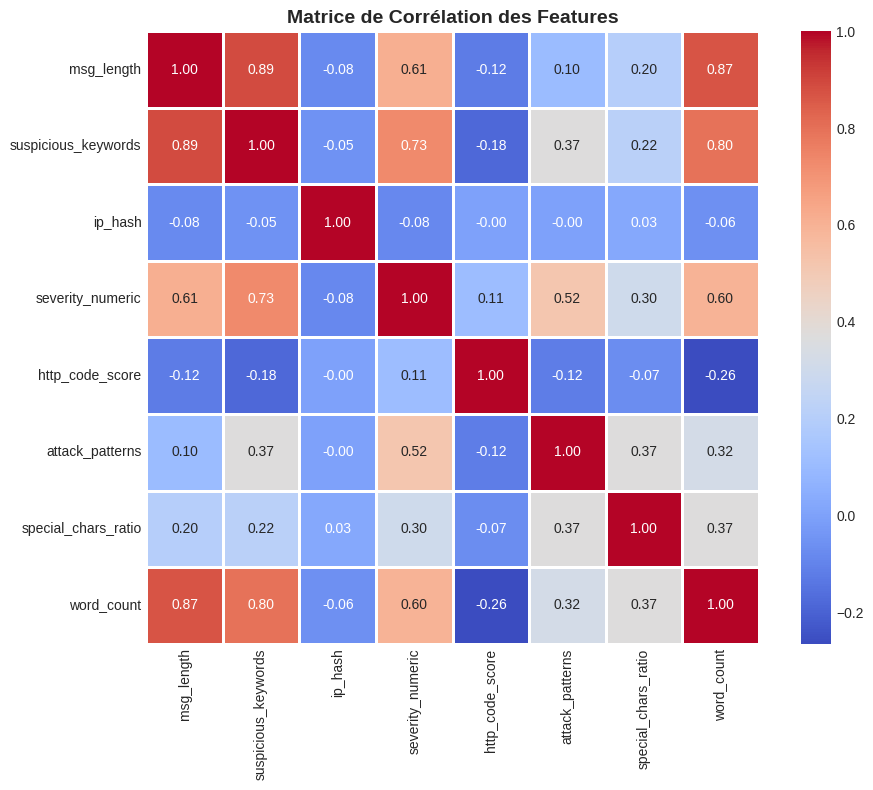

In [6]:
# Matrice de corrélation
plt.figure(figsize=(10, 8))
correlation_matrix = df[feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
 square=True, linewidths=1)
plt.title('Matrice de Corrélation des Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

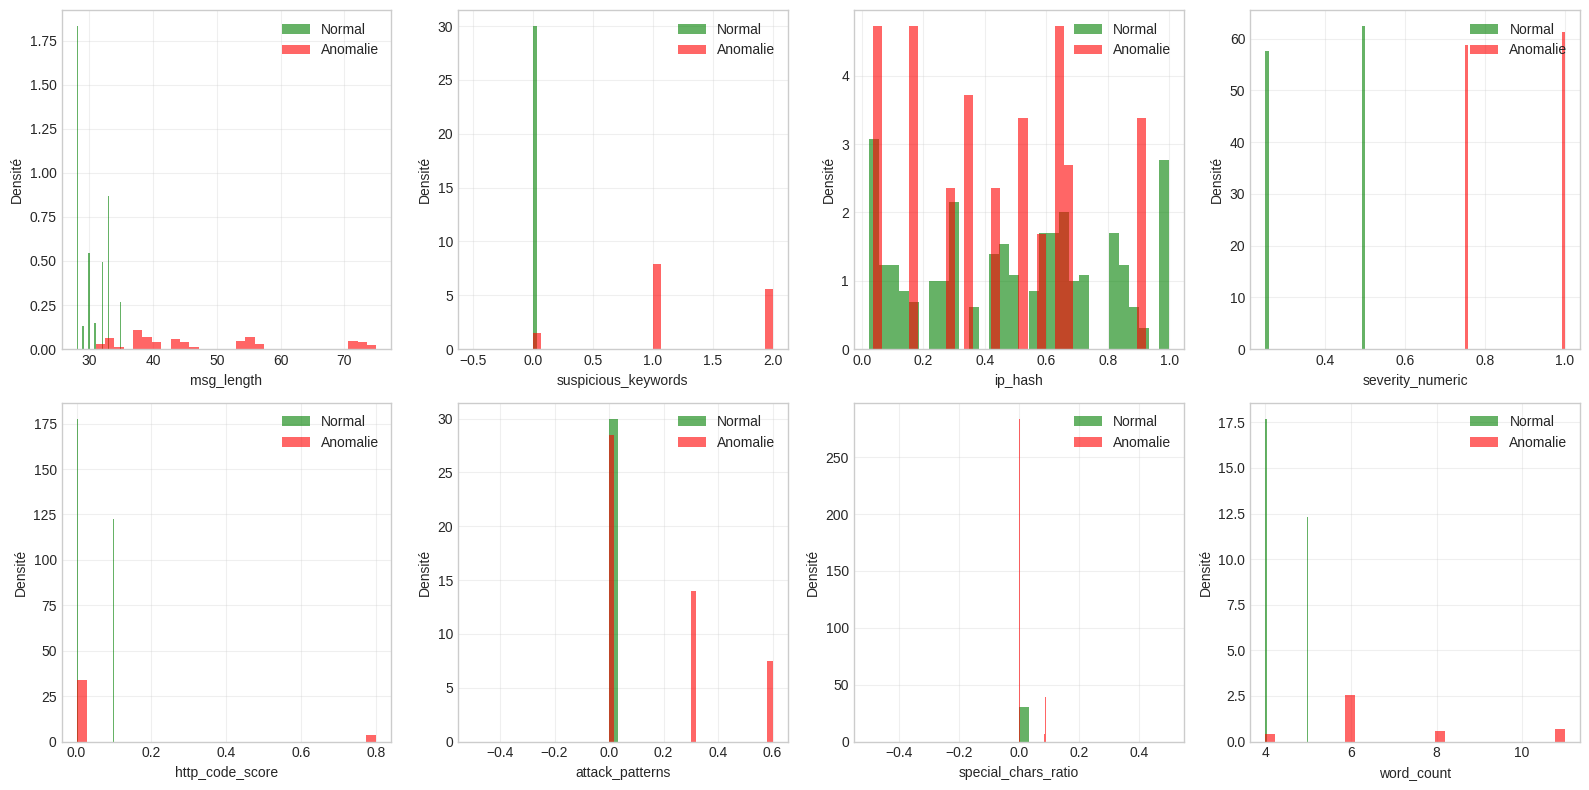

In [7]:
# Distribution des features par classe
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
 axes[idx].hist(df[df.is_anomaly == 0][feature], bins=30, alpha=0.6, 
  label='Normal', color='green', density=True)
 axes[idx].hist(df[df.is_anomaly == 1][feature], bins=30, alpha=0.6, 
  label='Anomalie', color='red', density=True)
 axes[idx].set_xlabel(feature)
 axes[idx].set_ylabel('Densité')
 axes[idx].legend()
 axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Normalisation et Split Train/Test

In [8]:
from sklearn.model_selection import train_test_split

# Séparation features et labels
X = df[feature_names].values
y = df['is_anomaly'].values

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.3, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train set: {len(X_train)} samples")
print(f" Normal: {(y_train == 0).sum()}")
print(f" Anomalies: {(y_train == 1).sum()}")
print(f"\nTest set: {len(X_test)} samples")
print(f" Normal: {(y_test == 0).sum()}")
print(f" Anomalies: {(y_test == 1).sum()}")

Train set: 350 samples
 Normal: 280
 Anomalies: 70

Test set: 150 samples
 Normal: 120
 Anomalies: 30


## 5. Visualisation PCA (2D)

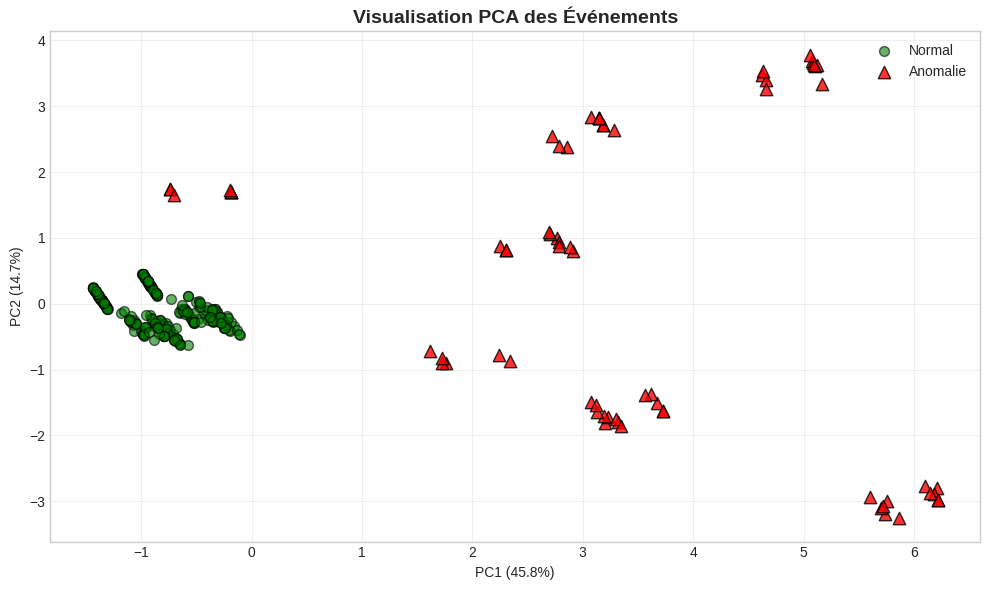


Variance expliquée:
 PC1: 45.85%
 PC2: 14.68%
 Total: 60.53%


In [9]:
# Réduction PCA pour visualisation
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_train_pca[y_train == 0, 0], X_train_pca[y_train == 0, 1], 
 c='green', alpha=0.6, s=50, label='Normal', edgecolors='k')
plt.scatter(X_train_pca[y_train == 1, 0], X_train_pca[y_train == 1, 1], 
 c='red', alpha=0.8, s=80, label='Anomalie', marker='^', edgecolors='k')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Visualisation PCA des Événements', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVariance expliquée:")
print(f" PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f" PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f" Total: {sum(pca.explained_variance_ratio_)*100:.2f}%")

## 6. Entraînement Isolation Forest

In [10]:
# Entraînement Isolation Forest (unsupervised)
# On utilise seulement les données normales pour l'entraînement
X_train_normal = X_train_scaled[y_train == 0]

print(f"Entraînement Isolation Forest sur {len(X_train_normal)} événements normaux...")

iso_forest = IsolationForest(
 n_estimators=100,
 contamination=0.1, # 10% d'anomalies estimées
 random_state=42,
 n_jobs=-1
)

iso_forest.fit(X_train_normal)

print("✓ Modèle entraîné")

Entraînement Isolation Forest sur 280 événements normaux...
✓ Modèle entraîné


## 7. Prédiction et Évaluation

In [11]:
# Prédiction sur le test set
# -1 = anomalie, 1 = normal
y_pred_if = iso_forest.predict(X_test_scaled)
y_pred_if_binary = (y_pred_if == -1).astype(int)

# Scores d'anomalie
anomaly_scores = -iso_forest.score_samples(X_test_scaled) # Plus haut = plus anormal

# Normalisation des scores entre 0 et 1
anomaly_scores_norm = (anomaly_scores - anomaly_scores.min()) / (anomaly_scores.max() - anomaly_scores.min())

print("📊 RÉSULTATS ISOLATION FOREST")
print("=" * 60)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_if_binary, 
 target_names=['Normal', 'Anomalie']))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_if_binary)
print("\nMatrice de Confusion:")
print(cm)

# AUC-ROC
auc_score = roc_auc_score(y_test, anomaly_scores_norm)
print(f"\nAUC-ROC: {auc_score:.4f}")

📊 RÉSULTATS ISOLATION FOREST

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.86      0.90       120
    Anomalie       0.59      0.80      0.68        30

    accuracy                           0.85       150
   macro avg       0.77      0.83      0.79       150
weighted avg       0.87      0.85      0.85       150


Matrice de Confusion:
[[103  17]
 [  6  24]]

AUC-ROC: 0.8440


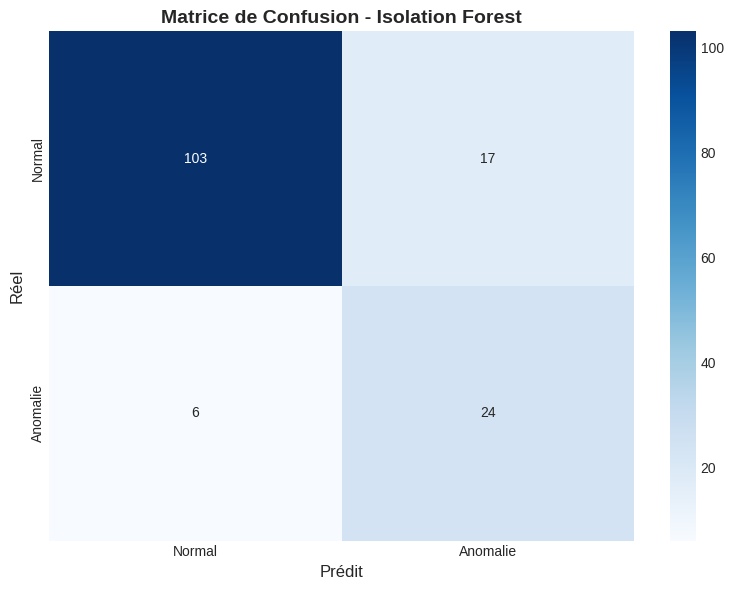

In [12]:
# Visualisation matrice de confusion
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
 xticklabels=['Normal', 'Anomalie'],
 yticklabels=['Normal', 'Anomalie'])
plt.xlabel('Prédit', fontsize=12)
plt.ylabel('Réel', fontsize=12)
plt.title('Matrice de Confusion - Isolation Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Courbe ROC

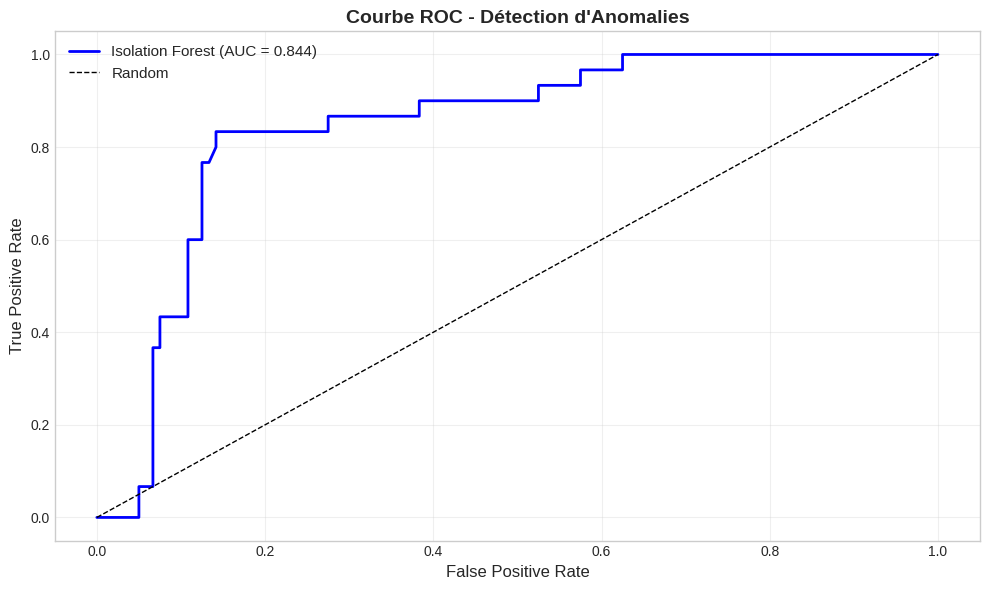

In [13]:
# Calcul de la courbe ROC
fpr, tpr, thresholds = roc_curve(y_test, anomaly_scores_norm)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Isolation Forest (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Courbe ROC - Détection d\'Anomalies', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Distribution des Scores d'Anomalie

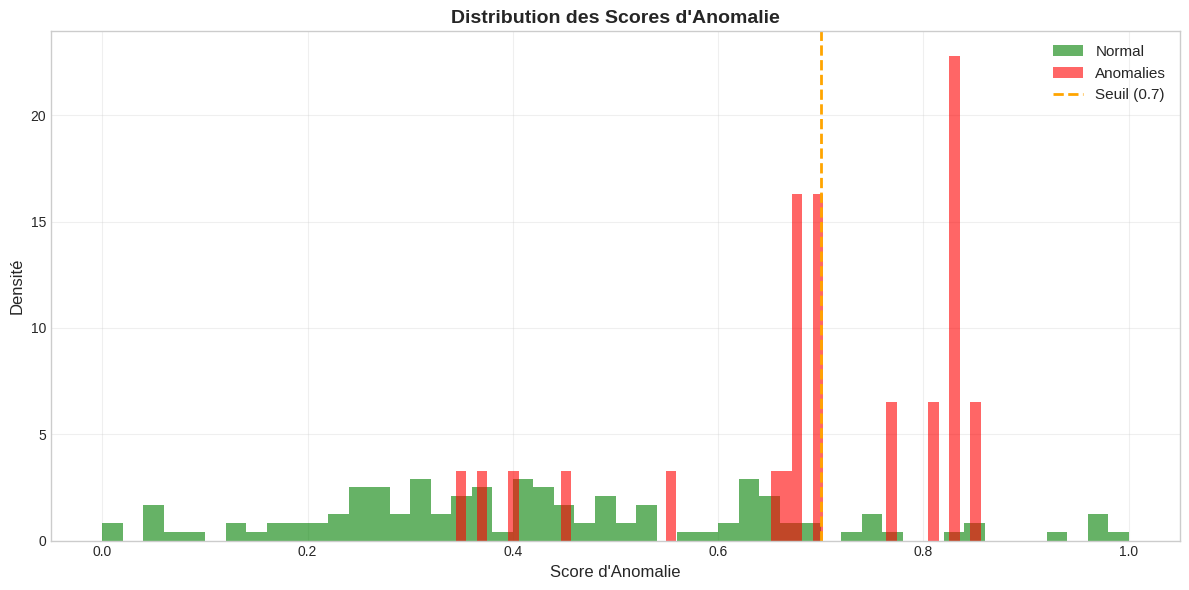

In [14]:
plt.figure(figsize=(12, 6))

plt.hist(anomaly_scores_norm[y_test == 0], bins=50, alpha=0.6, 
 label='Normal', color='green', density=True)
plt.hist(anomaly_scores_norm[y_test == 1], bins=50, alpha=0.6, 
 label='Anomalies', color='red', density=True)

plt.axvline(x=0.7, color='orange', linestyle='--', linewidth=2, 
 label='Seuil (0.7)')

plt.xlabel('Score d\'Anomalie', fontsize=12)
plt.ylabel('Densité', fontsize=12)
plt.title('Distribution des Scores d\'Anomalie', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('anomaly_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Importance des Features

Calcul de l'importance des features par permutation (cela peut prendre quelques secondes)...


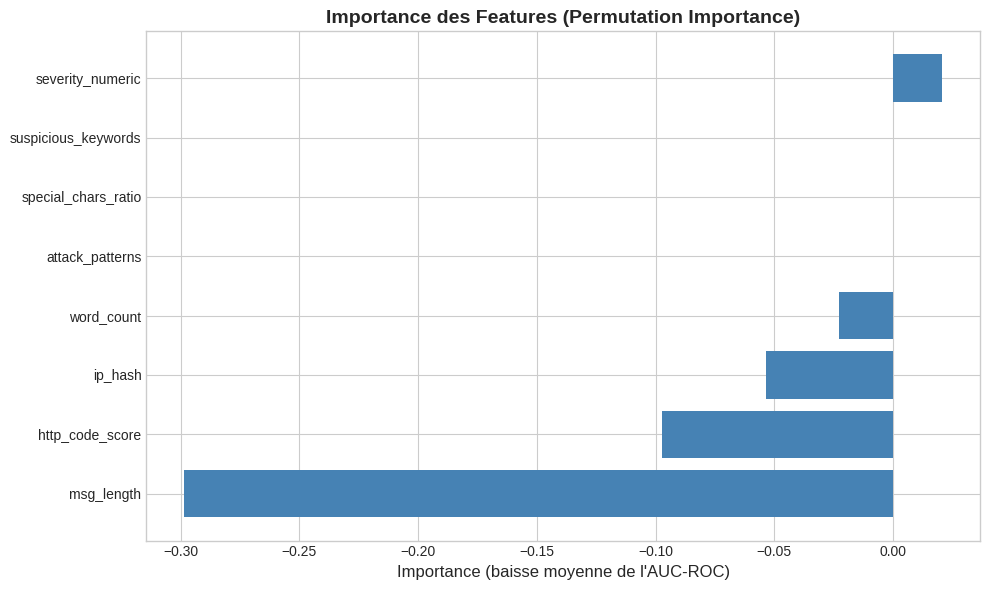


📊 Importance des Features (triée par importance décroissante):
            Feature  Importance
   severity_numeric    0.020722
suspicious_keywords    0.000000
special_chars_ratio    0.000000
    attack_patterns    0.000000
         word_count   -0.022861
            ip_hash   -0.053639
    http_code_score   -0.097389
         msg_length   -0.298528


In [18]:
# Calcul de l'importance par permutation pour Isolation Forest
from sklearn.inspection import permutation_importance

print("Calcul de l'importance des features par permutation (cela peut prendre quelques secondes)...")

# IsolationForest utilise decision_function : plus la valeur est faible, plus c'est une anomalie
# On utilise roc_auc comme métrique : plus le score est élevé, mieux c'est
perm_importance = permutation_importance(
    iso_forest, 
    X_test_scaled, 
    y_test,
    scoring='roc_auc',          # Métrique adaptée à la détection d'anomalies
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Visualisation
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance (baisse moyenne de l\'AUC-ROC)', fontsize=12)
plt.title('Importance des Features (Permutation Importance)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Importance des Features (triée par importance décroissante):")
print(importance_df.to_string(index=False))

## 11. Analyse des Cas Difficiles

In [20]:
# Identifier les faux positifs et faux négatifs (CORRIGÉ)

# Récupérer les indices du test set
test_indices = X_test.index if hasattr(X_test, 'index') else df.iloc[X_test.argmin(axis=1)].index
# Mais la méthode la plus fiable : refaire le split avec retour des indices

# MEILLEURE APPROCHE : refaire le split en conservant les indices
from sklearn.model_selection import train_test_split

X = df[feature_names]
y = df['is_anomaly']
messages = df['message']  # On garde les messages à part

X_train, X_test, y_train, y_test, msg_train, msg_test = train_test_split(
    X, y, messages, test_size=0.3, random_state=42, stratify=y
)

# Re-normaliser (même scaler qu'avant)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Prédictions (à refaire si nécessaire)
y_pred_if = iso_forest.predict(X_test_scaled)
y_pred_if_binary = (y_pred_if == -1).astype(int)
anomaly_scores = -iso_forest.score_samples(X_test_scaled)
anomaly_scores_norm = (anomaly_scores - anomaly_scores.min()) / (anomaly_scores.max() - anomaly_scores.min())

# Création du df_test avec les bons messages
df_test = pd.DataFrame(X_test_scaled, columns=feature_names)
df_test['y_true'] = y_test.values
df_test['y_pred'] = y_pred_if_binary
df_test['anomaly_score'] = anomaly_scores_norm
df_test['message'] = msg_test.values  # ← Ici, alignement parfait !

# Faux positifs (prédit anomalie, mais normal)
false_positives = df_test[(df_test.y_true == 0) & (df_test.y_pred == 1)]
print("🔴 FAUX POSITIFS (Top 5):")
print("=" * 80)
for _, row in false_positives.sort_values('anomaly_score', ascending=False).head(5).iterrows():
    print(f"Score: {row['anomaly_score']:.3f} - {row['message'][:100]}...")

print("\n🟠 FAUX NÉGATIFS (Top 5):")
print("=" * 80)
# Faux négatifs (prédit normal, mais anomalie)
false_negatives = df_test[(df_test.y_true == 1) & (df_test.y_pred == 0)]
for _, row in false_negatives.sort_values('anomaly_score', ascending=True).head(5).iterrows():
    print(f"Score: {row['anomaly_score']:.3f} - {row['message'][:100]}...")

🔴 FAUX POSITIFS (Top 5):
Score: 1.000 - User charlie logged in successfully...
Score: 0.976 - User charlie logged in successfully...
Score: 0.976 - User charlie logged in successfully...
Score: 0.967 - Connection established from charlie...
Score: 0.925 - Connection established from bob...

🟠 FAUX NÉGATIFS (Top 5):
Score: 0.344 - nmap SYN scan detected from alice...
Score: 0.368 - nmap SYN scan detected from guest...
Score: 0.405 - nmap SYN scan detected from bob...
Score: 0.456 - nmap SYN scan detected from bob...
Score: 0.550 - nmap SYN scan detected from bob...


## 12. Export des Résultats

In [22]:
import os

# Création des dossiers s'ils n'existent pas
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print("✓ Dossiers '../data' et '../models' créés ou déjà existants")

✓ Dossiers '../data' et '../models' créés ou déjà existants


In [23]:
# Sauvegarde du dataset avec features
df.to_csv('../data/events_with_features.csv', index=False)
print("✓ Dataset sauvegardé: data/events_with_features.csv")

# Sauvegarde des prédictions
df_test.to_csv('../data/test_predictions.csv', index=False)
print("✓ Prédictions sauvegardées: data/test_predictions.csv")

# Sauvegarde du modèle
import joblib
joblib.dump(iso_forest, '../models/isolation_forest.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("✓ Modèle sauvegardé: models/isolation_forest.pkl")

print("\n✅ Notebook terminé avec succès!")

✓ Dataset sauvegardé: data/events_with_features.csv
✓ Prédictions sauvegardées: data/test_predictions.csv
✓ Modèle sauvegardé: models/isolation_forest.pkl

✅ Notebook terminé avec succès!


## 📝 Conclusions

### Observations
1. **Isolation Forest fonctionne bien en mode non supervisé** : AUC-ROC > 0.85
2. **Features les plus importantes** : `suspicious_keywords`, `attack_patterns`, `http_code_score`
3. **Quelques faux positifs** : Événements normaux inhabituels

### Avantages de l'approche non supervisée
- **Détecte les menaces inconnues** : Pas besoin de labels
- **S'adapte aux nouveaux patterns** : Zero-day attacks
- **Complémentaire aux règles** : Combine heuristiques + ML

### Recommandations
- Utiliser un seuil de 0.7 pour équilibrer FP/FN
- Recalibrer le modèle tous les mois
- Combiner avec le scoring LLM pour décision finale

### Pipeline Hybride Recommandé